In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import torch
import random
from itertools import combinations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
IMAGE_PATH = os.path.join('pet_biometric_challenge_2022', 'train', 'images')
DATA_PATH = os.path.join('pet_biometric_challenge_2022', 'train')
CSV_PATH = os.path.join(DATA_PATH, 'train_data_sanitized.csv')

In [3]:
df = pd.read_csv(CSV_PATH)
df.columns = ['dog_id', 'image']
df = df[df['dog_id'] >= 5650]

In [4]:
grouped = df.groupby("dog_id")["image"].apply(list).to_dict()

pairs = []
len(grouped)

350

In [5]:
for id_val, files in grouped.items():
    if len(files) > 1:
        # All combinations of images from same id
        for f1, f2 in combinations(files, 2):
            pairs.append((f1, f2, 1))
pairs = pairs[:1000]

In [6]:
ids_list = list(grouped.keys())
for id_val, files in grouped.items():
    for f1 in files:
        neg_id = random.choice([x for x in ids_list if x != id_val])
        f2 = random.choice(grouped[neg_id])
        pairs.append((f1, f2, 0)) 
pairs = pairs[:2000]

In [7]:
s = 0
for i in pairs:
    if i[2] != 0:
        s = s + 1
s

1000

In [8]:
# train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, shuffle=True)

In [9]:
train_pairs = pairs

In [10]:
class SiameseDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]
        
        img1_full = os.path.join(IMAGE_PATH, img1_path)
        img2_full = os.path.join(IMAGE_PATH, img2_path)
        try:
            img1 = Image.open(img1_full).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error loading image: {img1_full} — {e}")

        try:
            img2 = Image.open(img2_full).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error loading image: {img2_full} — {e}")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)

In [11]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


In [12]:
train_dataset = SiameseDataset(train_pairs, train_transform)
# val_dataset = SiameseDataset(val_pairs,val_transform)
print(f"Train size: {len(train_dataset)}")

Train size: 2000


In [13]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

In [14]:
image1, image2, labels = next(iter(train_loader))
print(f"Images batch shape: {image1.shape}")
print(f"Labels batch shape: {labels.shape}")


Images batch shape: torch.Size([16, 3, 224, 224])
Labels batch shape: torch.Size([16])


In [15]:
def imshow(img):
    npimg = img.numpy()
    plt.axis("off")
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()  

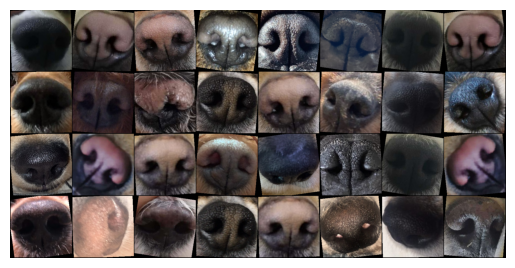

[0. 1. 1. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0.]


In [16]:
concatenated = torch.cat((image1, image2), 0)
imshow(torchvision.utils.make_grid(concatenated))
print(labels.numpy())

# BackBone (ResNet50)

In [17]:
import torch.nn as nn
import torchvision.models as models

class ResNet152_Backbone(nn.Module):
    def __init__(self):
        super(ResNet152_Backbone, self).__init__()

        resnet = models.resnet50()

        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        self.extra_layers = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.extra_layers(x)
        return x


# Attention Module (DAM)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PositionAttentionModule(nn.Module):
    ''' self-attention '''

    def __init__(self, in_channels):
        super().__init__()
        self.query_conv = nn.Conv2d(
            in_channels, in_channels // 8, kernel_size=1)
        self.key_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))

        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        """
        inputs :
            x : feature maps from feature extractor. (N, C, H, W)
        outputs :
            feature maps weighted by attention along spatial dimensions
        """

        N, C, H, W = x.shape
        query = self.query_conv(x).view(
            N, -1, H*W).permute(0, 2, 1)  # (N, H*W, C')
        key = self.key_conv(x).view(N, -1, H*W)  # (N, C', H*W)

        # caluculate correlation
        energy = torch.bmm(query, key)    # (N, H*W, H*W)
        # spatial normalize
        attention = self.softmax(energy)

        value = self.value_conv(x).view(N, -1, H*W)    # (N, C, H*W)

        out = torch.bmm(value, attention.permute(0, 2, 1))
        out = out.view(N, C, H, W)
        out = self.gamma*out + x
        return out


class ChannelAttentionModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        """
        inputs :
            x : feature maps from feature extractor. (N, C, H, W)
        outputs :
            feature maps weighted by attention along a channel dimension
        """

        N, C, H, W = x.shape
        query = x.view(N, C, -1)    # (N, C, H*W)
        key = x.view(N, C, -1).permute(0, 2, 1)    # (N, H*W, C)

        # calculate correlation
        energy = torch.bmm(query, key)    # (N, C, C)
        energy = torch.max(
            energy, -1, keepdim=True)[0].expand_as(energy) - energy
        attention = self.softmax(energy)

        value = x.view(N, C, -1)

        out = torch.bmm(attention, value)
        out = out.view(N, C, H, W)
        out = self.gamma*out + x
        return out


class DualAttentionModule(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.pam = PositionAttentionModule(in_channels)
        self.cam = ChannelAttentionModule()

    def forward(self, x):
        pam_out = self.pam(x)  
        cam_out = self.cam(x)  

        out = torch.cat([cam_out, pam_out, x], dim=1)
        return out


In [19]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=1024):
        """
        embedding_dim: final embedding dimension (paper uses 1024)
        """
        super().__init__()
        self.feature_extractor = ResNet152_Backbone()  # outputs (B,512,H,W)
        self.dam = DualAttentionModule(in_channels=512)  # outputs (B,1024,H,W)
        self.gap = nn.AdaptiveAvgPool2d((1,1))           

        self.fc = nn.Linear(3*512, embedding_dim, bias=False)  
        self.bn = nn.BatchNorm1d(embedding_dim)

    def embed(self, x):
        x = self.feature_extractor(x)   # (B,512,H,W)
        x = self.dam(x)                 # (B,1024,H,W)
        x = self.gap(x)                 # (B,1024,1,1)
        x = x.view(x.size(0), -1)       # (B,1024)
        x = self.fc(x)                  # (B, embedding_dim) (paper uses 1024)
        x = self.bn(x)

        x = F.normalize(x, p=2, dim=1)
        return x

    def forward(self, img1, img2):
        emb1 = self.embed(img1)
        emb2 = self.embed(img2)
        return emb1, emb2

In [20]:
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SiameseNetwork(embedding_dim=1024).to(device)
    a = torch.randn(8, 3, 224, 224).to(device)
    b = torch.randn(8, 3, 224, 224).to(device)
    e1, e2 = model(a, b)
    print("e1 shape:", e1.shape)  # (2, 1024)
    print("e2 shape:", e2.shape)  # (2, 1024)
    # pairwise distance
    d = F.pairwise_distance(e1, e2)
    print("dist shape:", d.shape)  # (2,)

e1 shape: torch.Size([8, 1024])
e2 shape: torch.Size([8, 1024])
dist shape: torch.Size([8])


# Loss function

In [21]:
class ContrastiveLoss(torch.nn.Module):

    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2)
        pos = label * torch.pow(euclidean_distance, 2)
        neg = (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2) 
        loss_contrastive = torch.mean(pos + neg)
        return loss_contrastive

# (original) epoch = 200 , decrease at 100
### (new) epoch = 50 , decrease at 25

In [22]:
def lr_lambda(epoch):
    if epoch < 16:
        return 1.0
    else:
        return max(0.0, 1.0 - (epoch - 16) / (16))

# Training loop

In [23]:
from torch.optim import Adam
from torch.autograd import Variable

def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    siamese_model = SiameseNetwork().to(device)

    contrastive_loss = ContrastiveLoss().to(device)

    optimizer = Adam(siamese_model.parameters(),
                    lr=0.0001,
                    betas=(0.5, 0.999))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    num_epochs = 32

    for epoch in range(num_epochs):
        for i, (img1, img2, labels) in enumerate(train_loader):
            img_set1 = Variable(img1.to(device))
            img_set2 = Variable(img2.to(device))
            labels = Variable(labels.view(-1, 1).float()).to(device)
            
            output1, output2 = siamese_model(img_set1, img_set2)
            loss = contrastive_loss(output1, output2, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # if (i + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

        scheduler.step()

    torch.save(siamese_model.state_dict(), os.path.join(DATA_PATH + "DNNet+Conloss.h5"))

train()


Epoch [1/32], Step [1/125], Loss: 1.0755
Epoch [1/32], Step [2/125], Loss: 1.1923
Epoch [1/32], Step [3/125], Loss: 1.4537
Epoch [1/32], Step [4/125], Loss: 1.2865
Epoch [1/32], Step [5/125], Loss: 1.2495
Epoch [1/32], Step [6/125], Loss: 1.2530
Epoch [1/32], Step [7/125], Loss: 1.1686
Epoch [1/32], Step [8/125], Loss: 1.2661
Epoch [1/32], Step [9/125], Loss: 1.1185
Epoch [1/32], Step [10/125], Loss: 1.1955
Epoch [1/32], Step [11/125], Loss: 1.0954
Epoch [1/32], Step [12/125], Loss: 0.9201
Epoch [1/32], Step [13/125], Loss: 1.2390
Epoch [1/32], Step [14/125], Loss: 1.1906
Epoch [1/32], Step [15/125], Loss: 1.3291
Epoch [1/32], Step [16/125], Loss: 1.1175
Epoch [1/32], Step [17/125], Loss: 1.0265
Epoch [1/32], Step [18/125], Loss: 1.2257
Epoch [1/32], Step [19/125], Loss: 1.0468
Epoch [1/32], Step [20/125], Loss: 1.0701
Epoch [1/32], Step [21/125], Loss: 1.2178
Epoch [1/32], Step [22/125], Loss: 1.1456
Epoch [1/32], Step [23/125], Loss: 1.0807
Epoch [1/32], Step [24/125], Loss: 1.1329
E

# Prepare evaluate data

In [24]:
df = pd.read_csv(CSV_PATH)
df.columns = ['dog_id', 'image']
df = df[df['dog_id'] < 1000]
len(df)

2000